# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Movielens data querying and analysis using NoSQL Database

## Problem Statement

Using the Cassandra NoSQL database, explore the **Movielens** dataset and build a movie recommendation engine

## Learning Objectives

At the end of the mini-project, you will be able to :

* understand the concepts of NoSQL platforms
* implement the database connectivity using Cassandra
* create and insert data to the database
* perform querying, retrieving and analyzing the data from database

### Dataset

The dataset chosen for this mini-project is [Movielens Dataset](https://movielens.org/). The dataset describes movies and ratings from Movielens. It contains movies from year 1919 to 2000 of total 3883 movies. There are 6040 users who have rated one or more than one movie of total 1000209 ratings collected. Movielens is maintained by members of GroupLens Research at the University of Minnesota. There are 3 datasets given, and they are:

1. `data_movie.csv` that contains movies information:

* MovieId
* Title
* Genres

2. `data_rating.csv` that contains ratings of movies by users:

* UserId
* MovieId
* Rating

3. `data_users.csv` that contains users information:

* UserId
* Age
* Gender

## Information

#### NoSQL platforms

A NoSQL database provides a mechanism for storage and retrieval of data that is modeled in a form other than the tabular relations used in relational databases.

**Cassandra**

Apache Cassandra is a free and open-source, distributed, wide-column store, NoSQL database management system designed to handle large amounts of data across many commodity servers, providing high availability with no single point of failure. It is a NOSQL database developed by Facebook. It is a great database that allows you to effectively run queries on large amount of structured and semi structured data.

To know when you have to choose Cassandra as your database of choice, you need to have an understanding of CAP Theorem.

CAP theorem states that it is impossible for a distributed system to satisfy all three of these guarantees together, you need to leave one out.

- C is Consistency, means all nodes have the same data at the same time
- P is partition tolerance, means that in case of failure the system continues to operate
- A is availability , make sure every request receives a response

![img](https://developer.ibm.com/developer/default/tutorials/ba-set-up-apache-cassandra-architecture/images/figure1.png)

### Components of Cassandra

There are following components in the Cassandra

![img](https://www.guru99.com/images/cassandra/021116_0524_CassandraAr1.png)

**Node**
Node is the place where data is stored. It is the basic component of Cassandra.

**Data Center**
A collection of nodes are called data center. Many nodes are categorized as a data center.

**Cluster**
The cluster is the collection of many data centers.

**Commit Log**
Every write operation is written to Commit Log. Commit log is used for crash recovery.

**Mem-table**
After data written in Commit log, data is written in Mem-table. Data is written in Mem-table temporarily.

**SSTable**
When Mem-table reaches a certain threshold, data is flushed to an SSTable disk file.

### Data Replication

As hardware problem can occur or link can be down at any time during data process, a solution is required to provide a backup when the problem has occurred. So data is replicated for assuring no single point of failure.

Cassandra places replicas of data on different nodes based on these two factors.
- Where to place next replica is determined by the Replication Strategy.
- While the total number of replicas placed on different nodes is determined by the Replication Factor.

One Replication factor means that there is only a single copy of data while three replication factor means that there are three copies of the data on three different nodes.

## Grading = 10 Points

**Install the cassandra-driver**

In [229]:
# !pip install cassandra-driver
# installed using uv
# uv add cassandra-driver
# as per the documentation https://docs.datastax.com/en/developer/python-driver/3.29/installation/index.html
# brew install libev
# point to python 3.11


#### Importing Necessary Packages

In [230]:
import os

import pandas as pd
from pandas import DataFrame
import cassandra
from cassandra.cluster import Cluster
from cassandra.auth import PlainTextAuthProvider
from matplotlib import pyplot as plt
from dotenv import load_dotenv


In [231]:
print(cassandra.__version__)


3.29.2


In [232]:
load_dotenv()
# Enter the credentials below

zip_path = os.getenv("ZIP_PATH")
Client_ID = os.getenv("CLIENT_ID")
Client_Secret = os.getenv("CLIENT_SECRET")


### Database connection (2 points)

**Astra Datastax login:** Please refer to this [document](https://cdn.iisc.talentsprint.com/CDS/DB_Connect_Docs/Datastax_Connect.pdf) for account creation on DataStax

**Connect the database and create keyspace:**

* Download Secure Connect Bundle zip file from Datastax [connect](https://docs.datastax.com/en/astra/docs/obtaining-database-credentials.html) section. Follow the instructions on the page
* Upload the `Secure-connect-XXXX.zip` file, which is downloaded from datastax.
* Generate the token and save the credentials from settings section.
    - Hint: Select role as `admin-user` and generate token
* Using the credentials generated in settings, specify the `client Id` and `Client Secret` to the variables below.

In [233]:
# @title Download bundle zip
# !wget -qq https://cdn.exec.talentsprint.com/static/cds/content/secure_connect_cds_mov_database.zip
# !wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_movies.csv
# !wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_ratings.csv
# !wget -qq https://cdn.exec.talentsprint.com/static/cds/content/data_users.csv

from utility import download_and_unzip

file_names = [
    # "secure_connect_cds_mov_database.zip",
    "data_movies.csv",
    "data_ratings.csv",
    "data_users.csv",
]

urls = [
    # "https://cdn.exec.talentsprint.com/static/cds/content/secure_connect_cds_mov_database.zip",
    "https://cdn.exec.talentsprint.com/static/cds/content/data_movies.csv",
    "https://cdn.exec.talentsprint.com/static/cds/content/data_ratings.csv",
    "https://cdn.exec.talentsprint.com/static/cds/content/data_users.csv",
]

for filename, url in zip(file_names, urls):
    download_and_unzip(filename=filename, url=url)

print("Data downloaded successfully")


Data downloaded successfully


In [234]:
# from google.colab import files
# files.upload()


set the `Secure connect bundle zip file` path and specify the `clientID` and `Client_Secret`

Note: Credentials used are from CDS account on Datastax

**Database details:**

Database name: cds_mov_database

Namespace name: cds_mov

Collection name: cds_mov_collection

Collection name: cds_rating_collection

Collection name: cds_user_collection

zip_path = '/content/secure-connect-cds-mov-database.zip'

Client_ID = 'Your_Client_ID'

Client_Secret = 'Your_Client_Secret'

#### Create a Cluster instance to connect to your Astra database.

You will typically have one instance of Cluster for each Cassandra cluster you want to interact with. Create a session object using the cluster.

**Hint:** Refer Python documentation under Connect.

In [235]:
# Set event loop manager before importing cassandra modules
os.environ["CASSANDRA_EVENT_LOOP_MANAGER"] = "asyncio"

# Use already defined variables from the notebook
cloud_config = {"secure_connect_bundle": zip_path}
auth_provider = PlainTextAuthProvider(Client_ID, Client_Secret)
cluster = Cluster(cloud=cloud_config, auth_provider=auth_provider)
session = cluster.connect()

row = session.execute("select release_version from system.local").one()
if row:
    print(row[0])
else:
    print("An error occurred.")


4.0.11.0-cea3b83ec125


#### Some useful reading
https://awesome-astra.github.io/docs/pages/astra/create-account/#1-overview

![Components Logical Relationship](logical-relationship.png "Component's Logical Relationship")

#### Some useful commands to interact with astraDB via cli

```bash
❯ brew install datastax/astra-cli/astra-cli

❯ astra
usage: astra <command> [ <args> ]

Commands are:
    ?           Display this help version
    help        Display help information
    login       Authenticate against Astra.
    setup       Initialize configuration file
    config      Manage configuration file
    db          Manage databases
    org         Display Organization Info
    role        Manage roles
    streaming   Manage Streaming tenants
    token       Manage tokens
    user        Manage users

See 'astra help <command>' for more information on a specific command.

Sample commands :
 ️    List databases         : astra db list
 ️    Create vector database : astra db create demo --vector
 ️    List collections       : astra db list-collections demo

❯ astra setup --token="AstraCS:....."
[OK]    Configuration has been saved.
[OK]    Setup completed.
[INFO]  Enter 'astra help' to list available commands.

❯ astra --version
0.6

❯ astra config list
+-----------------------------------------+
| configuration                           |
+-----------------------------------------+
| rajranja@redhat.com (in use)            |
+-----------------------------------------+

# list the available databases
❯ astra db list
+---------------------+--------------------------------------+-------------+-------+---+-----------+
| Name                | id                                   | Regions     | Cloud | V | Status    |
+---------------------+--------------------------------------+-------------+-------+---+-----------+
| cds                 | 7972f89a-39d0-4951-a3ab-ea25c419fd1a | asia-south1 | gcp   |   | ACTIVE    |
+---------------------+--------------------------------------+-------------+-------+---+-----------+

# Create Database
❯ astra db create demo

# Resume Database
❯ astra db resume hemidactylus

# Get Database Details
❯ astra db get cds
+------------------+-----------------------------------------+
| Attribute        | Value                                   |
+------------------+-----------------------------------------+
| Name             | cds                                     |
| id               | 7972f89a-39d0-4951-a3ab-ea25c419fd1a    |
| Cloud            | GCP                                     |
| Regions          | asia-south1                             |
| Status           | ACTIVE                                  |
| Vector           | Disabled                                |
| Default Keyspace | movielens                               |
| Creation Time    | 2025-08-14T09:54:53Z                    |
| Keyspaces        | [0] movielens                           |
| Regions          | [0] asia-south1                         |
+------------------+-----------------------------------------+

#  Download Secure Connect Bundle
❯ mkdir db-demo; cd db-demo; astra db download-scb cds; ls

# Querying with CQLSH
# CQLSH is a standalone interface to work with Astra using CQL (Cassandra Query Language). With CQLSH, you can execute any number of CQL operations on the database including creating tables, querying data, and much, much more.
# Below will install a local cqlsh tool in the local .venv
❯ uv pip install cqlsh
Audited 1 package in 3ms

# start a new virtual env
❯ source .venv/bin/activate

# Get a session with database instance
❯ astra db cqlsh cds
[INFO]  Cqlsh is starting, please wait for connection establishment...
Connected to cndb at 127.0.0.1:9042.
[cqlsh 6.8.0 | Cassandra 4.0.0.6816 | CQL spec 3.4.5 | Native protocol v4]
Use HELP for help.
token@cqlsh> 

# To execute a CQL Statement with cqlsh, use the flag -e.
# Option 1
token@cqlsh> describe keyspaces

system_auth    system              movielens
system_schema  data_endpoint_auth  system_views
datastax_sla   system_traces       system_virtual_schema

# Option 2
❯ astra db cqlsh cds -e "describe keyspaces";
[INFO]  Cqlsh is starting, please wait for connection establishment...

system_auth    system              movielens
system_schema  data_endpoint_auth  system_views
datastax_sla   system_traces       system_virtual_schema

# To execute CQL Files with cqlsh, use the flag -f. You can also use the CQL syntax SOURCE.
❯ astra db cqlsh cds -f sample.cql

# Delete Database
❯ astra db delete cds


❯ 

```

#### Verifying the database connection

execute a simple query and verify the database connection

In [236]:
# YOUR CODE HERE
import os
from astrapy import DataAPIClient, Database


def connect_to_database() -> Database:
    """
    Connects to a DataStax Astra database.
    This function retrieves the database endpoint and application token from the
    environment variables `API_ENDPOINT` and `APPLICATION_TOKEN`.

    Returns:
        Database: An instance of the connected database.

    Raises:
        RuntimeError: If the environment variables `API_ENDPOINT` or
        `APPLICATION_TOKEN` are not defined.
    """
    endpoint = os.environ.get("API_ENDPOINT")
    token = os.environ.get("APPLICATION_TOKEN")

    if not token or not endpoint:
        raise RuntimeError(
            "Environment variables API_ENDPOINT and APPLICATION_TOKEN must be defined"
        )

    # Create an instance of the `DataAPIClient` class
    client = DataAPIClient()

    # Get the database specified by your endpoint and provide the token
    database = client.get_database(endpoint, token=token)

    print(f"Connected to database {database.info().name}")

    return database


In [237]:
connect_to_database()


Connected to database cds


Database(api_endpoint="https://7972f89a-39d0-4951-a3ab-ea25c419fd1a-asia-south1.apps.astra.datastax.com", keyspace="default_keyspace", api_options=FullAPIOptions(token=StaticTokenProvider(AstraCS:crck...), ...))

#### Setting the Key Space

A keyspace is the top-level database object that controls the replication for the object it contains at each datacenter in the cluster. Keyspaces contain tables, materialized views and user-defined types, functions and aggregates. Typically, a cluster has one keyspace per application. Since replication is controlled on a per-keyspace basis, store data with different replication requirements (at the same datacenter) in different keyspaces.

Before creating tables and inserting data let's create and set the keyspace

* we can create keyspace manually on Datastax dashboard or also using the CQL command. (use lowercase to avoid errors)

    * [Hint](https://docs.datastax.com/en/cql-oss/3.x/cql/cql_reference/cqlCreateKeyspace.html)

* once the keyspace is created successfully, set the keyspace using the command `set_keyspace()`

#### command to retrieve the details on the keyspace already created.

https://docs.datastax.com/en/cql-oss/3.x/cql/cql_reference/cqlshDescribe.html

```bash
❯ astra db cqlsh cds -e "describe keyspace movielens";
[INFO]  Cqlsh is starting, please wait for connection establishment...

CREATE KEYSPACE movielens WITH replication = {'class': 'NetworkTopologyStrategy', 'asia-south1': '3'}  AND durable_writes = true;

CREATE TABLE movielens.data_movies (
    movieid int PRIMARY KEY,
    genres text,
    title text
) WITH additional_write_policy = '99p'
    AND bloom_filter_fp_chance = 0.01
    AND caching = {'keys': 'ALL', 'rows_per_partition': 'NONE'}
    AND comment = ''
    AND compaction = {'class': 'org.apache.cassandra.db.compaction.UnifiedCompactionStrategy'}
    AND compression = {'chunk_length_in_kb': '16', 'class': 'org.apache.cassandra.io.compress.LZ4Compressor'}
    AND crc_check_chance = 1.0
    AND default_time_to_live = 0
    AND gc_grace_seconds = 864000
    AND max_index_interval = 2048
    AND memtable_flush_period_in_ms = 0
    AND min_index_interval = 128
    AND read_repair = 'BLOCKING'
    AND speculative_retry = '99p';

CREATE TABLE movielens.data_users (
    userid int PRIMARY KEY,
    age int,
    gender text
) WITH additional_write_policy = '99p'
    AND bloom_filter_fp_chance = 0.01
    AND caching = {'keys': 'ALL', 'rows_per_partition': 'NONE'}
    AND comment = ''
    AND compaction = {'class': 'org.apache.cassandra.db.compaction.UnifiedCompactionStrategy'}
    AND compression = {'chunk_length_in_kb': '16', 'class': 'org.apache.cassandra.io.compress.LZ4Compressor'}
    AND crc_check_chance = 1.0
    AND default_time_to_live = 0
    AND gc_grace_seconds = 864000
    AND max_index_interval = 2048
    AND memtable_flush_period_in_ms = 0
    AND min_index_interval = 128
    AND read_repair = 'BLOCKING'
    AND speculative_retry = '99p';
```

In [238]:
# YOUR CODE HERE
try:
    session.set_keyspace("movielens")
except Exception as e:
    print(e)


### Insert the data into Database (1 point)

To insert the data into database, we can create a table in keyspace and insert the data by using CQL command or we can directly upload the data on the datstax dashboard using [Astra Dataloader](https://docs.datastax.com/en/astra/docs/develop/dev-upload-data.html)

As there is huge amount of data, insertion of data using CQL commands may take time, preferable method is Astra Dataloader.

* Download the below mentioned 3 datasets and upload to Datastax Astra dashboard using Astra Dataloader
    * [data_movies](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_movies.csv)
    * [data_ratings](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_ratings.csv)
    * [data_users](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_users.csv)
    
while uploading data using Datastax Astra dataloader you may encounter the below error message due to formatting issues or bulk data. In that case, click on upload button for second time for data upload.
![img](https://cdn.iisc.talentsprint.com/CDS/MiniProjects/data_upload_error.JPG)

Note: Cassandra also handles non-SQL data formats such as JSON (see [insert JSON data](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useInsertJSON.html)). However for the purpose of this Mini-project, we are using a tabular data format (.csv).

### Loading the data


In [239]:
# YOUR CODE HERE
# Use pd.read_csv('data_movies.csv')
df_movies = pd.read_csv("data_movies.csv")
print(f"number of rows in the dataframe: {df_movies.shape[0]}")
df_movies.head()


number of rows in the dataframe: 3883


,movieid,title,genres
0,3372,"Bridge at Remagen, The (1969)",Action|War
1,1584,Contact (1997),Drama|Sci-Fi
2,2731,"400 Blows, The (Les Quatre cents coups) (1959)",Drama
3,2713,Lake Placid (1999),Horror|Thriller
4,769,Marlene Dietrich: Shadow and Light (1996),Documentary


In [240]:
# YOUR CODE HERE
# Use pd.read_csv('data_movies.csv')
df_users = pd.read_csv("data_users.csv")
print(f"number of rows in the dataframe: {df_users.shape[0]}")
df_users.head()


number of rows in the dataframe: 6040


,userid,gender,age
0,1,F,1
1,2,M,56
2,3,M,25
3,4,M,45
4,5,M,25


In [241]:
df_ratings = pd.read_csv("data_ratings.csv")
print(f"number of rows in the dataframe: {df_ratings.shape[0]}")
df_ratings.head()


number of rows in the dataframe: 1000209


,movieid,rating,userid
0,2929,4,1119
1,480,3,2918
2,3536,5,5589
3,3181,3,4277
4,2916,3,4708


### Querying the database (2 points)

* Select First 10 rows of the data_movies table
* How many Users have watched the movie  `'Contact (1997)'` with MovieId = 1584
* Select the count of teenage male users

**Note:** For syntax related issues, try the **CQLConsole** on Datastax dashboard

**Hint:** [CQL command for select](https://docs.datastax.com/en/cql-oss/3.3/cql/cql_using/useQueryColumnsSort.html)

#### Creating the data_movies table

In [242]:
def check_table_exists(session, keyspace: str, table: str) -> bool:
    query = f"SELECT table_name FROM system_schema.tables WHERE keyspace_name='{keyspace}' AND table_name='{table}';"
    rows = session.execute(query)
    return rows.one() is not None


In [243]:
def create_table_ratings(session, keyspace: str, table: str):
    query = f"""
    CREATE TABLE IF NOT EXISTS {keyspace}.{table} (
        movieid INT,
        rating INT,
        userid INT,
        PRIMARY KEY ((userid, movieid))
    );
    """
    try:
        session.execute(query)
    except Exception as e:
        print(e)


In [244]:
def create_table_users(session, keyspace: str, table: str):
    query = f"""
    CREATE TABLE IF NOT EXISTS {keyspace}.{table} (
        userid INT,
        gender TEXT,
        age INT,
        PRIMARY KEY (userid)
    );
    """
    try:
        session.execute(query)
    except Exception as e:
        print(e)


In [245]:
def create_table_movies(session, keyspace: str, table: str):
    query = f"""
    CREATE TABLE IF NOT EXISTS {keyspace}.{table} (
        movieid INT,
        title TEXT,
        genres TEXT,
        PRIMARY KEY (movieid)
    );
    """
    try:
        session.execute(query)
    except Exception as e:
        print(e)


In [246]:
def get_query(session, query: str) -> cassandra.cluster.ResultSet:
    """
    Executes a query and returns the result.
    """
    try:
        rows = session.execute(query)
        print(f"Executed query: {query}")
        for row in rows:
            print(row)
        return rows
    except Exception as e:
        print(f"Error executing query: {e}")
        return None


In [247]:
def get_data_and_row_count_from_table(session, keyspace: str, table: str):
    query = f"SELECT count(*) FROM {keyspace}.{table};"
    get_query(session, query)

    query = f"SELECT * FROM {keyspace}.{table} LIMIT 5;"
    get_query(session, query)


In [248]:
def load_data_in_table_ratings(
    session, keyspace: str, table: str, df_ratings: DataFrame
):
    ratings_cols = ",".join(df_ratings.columns.values)
    for i, row in df_ratings.iterrows():
        query = "INSERT INTO movielens.data_ratings ({}) VALUES (%s, %s, %s)".format(
            ratings_cols
        )
        session.execute_async(query, tuple(row))


In [249]:
def load_data_in_table_users(session, keyspace: str, table: str, df_users: DataFrame):
    users_cols = ",".join(df_users.columns.values)
    for i, row in df_users.iterrows():
        query = "INSERT INTO movielens.data_users ({}) VALUES (%s, %s, %s)".format(
            users_cols
        )
        session.execute_async(query, tuple(row))


In [250]:
def load_data_in_table_movies(session, keyspace: str, table: str, df_movies: DataFrame):
    movies_cols = ",".join(df_movies.columns.values)
    for i, row in df_movies.iterrows():
        query = "INSERT INTO movielens.data_movies ({}) VALUES (%s, %s, %s)".format(
            movies_cols
        )
        session.execute_async(query, tuple(row))


In [251]:
movie_table_exists = check_table_exists(session, "movielens", "data_movies")
print(f"movie table exists: {movie_table_exists}")

user_table_exists = check_table_exists(session, "movielens", "data_users")
print(f"user table exists: {user_table_exists}")

rating_table_exists = check_table_exists(session, "movielens", "data_ratings")
print(f"rating table exists: {rating_table_exists}")


movie table exists: True
user table exists: True
rating table exists: True


In [252]:
if movie_table_exists:
    print("Movie table exist. Lets querying it.")
    get_data_and_row_count_from_table(session, "movielens", "data_movies")
else:
    print("Movie table does not exist. Lets create it before querying.")


Movie table exist. Lets querying it.
Executed query: SELECT count(*) FROM movielens.data_movies;
Row(count=3883)
Executed query: SELECT * FROM movielens.data_movies LIMIT 5;
Row(movieid=3372, genres='Action|War', title='Bridge at Remagen, The (1969)')
Row(movieid=1584, genres='Drama|Sci-Fi', title='Contact (1997)')
Row(movieid=2731, genres='Drama', title='400 Blows, The (Les Quatre cents coups) (1959)')
Row(movieid=2713, genres='Horror|Thriller', title='Lake Placid (1999)')
Row(movieid=769, genres='Documentary', title='Marlene Dietrich: Shadow and Light (1996)')


**Please note that the above code cell will take around 6 mins 30 secs to complete execution on CPU**

#### Creating the data_ratings table

**Limiting the DataFrame to the first 5000 rows**

In [253]:
# Limiting the DataFrame to the first 5000 rows
# data_ratings = data_ratings.head(
#     5000
# )

# Replace 'data_ratings' with your actual DataFrame


In [254]:
# Preparing to insert only the first 5000 rows

# Use the following:
# insert_query = (
#     f"INSERT INTO cds_mov.data_ratings ({data_ratings_cols}) VALUES (%s, %s, %s)"
# )

# Insert the 5000 rows into Cassandra table 'data_ratings'
# YOUR CODE HERE


In [255]:
if rating_table_exists:
    print("Rating table exist. Lets querying it.")
    get_data_and_row_count_from_table(session, "movielens", "data_ratings")
else:
    print("Rating table does not exist. Lets create it before querying.")


Rating table exist. Lets querying it.
Executed query: SELECT count(*) FROM movielens.data_ratings;
Row(count=78050)
Executed query: SELECT * FROM movielens.data_ratings LIMIT 5;
Row(userid=1119, movieid=2929, rating=4)
Row(userid=2918, movieid=480, rating=3)
Row(userid=5589, movieid=3536, rating=5)
Row(userid=4277, movieid=3181, rating=3)
Row(userid=4708, movieid=2916, rating=3)


**Please note that the above code cell will take around 8 mins 26 secs to complete execution on CPU**

#### Creating the data_users table

In [256]:
# Use the following SQL query:
# query = """CREATE TABLE  IF NOT EXISTS data_users (userid INT,
#                                                 gender TEXT,
#                                                 age INT,
#                                                 PRIMARY KEY (userid)); """


In [257]:
# data_users_cols = ",".join(data_users.columns.values)
# for i, row in data_users.iterrows():
#     query = "INSERT INTO cds_mov.data_users ({}) VALUES (%s, %s, %s)".format(
#         data_users_cols
#     )
#     session.execute(query, tuple(row))


In [258]:
if user_table_exists:
    print("User table exist. Lets querying it.")
    get_data_and_row_count_from_table(session, "movielens", "data_users")
else:
    print("User table does not exist. Lets create it before querying.")


User table exist. Lets querying it.
Executed query: SELECT count(*) FROM movielens.data_users;
Row(count=6040)
Executed query: SELECT * FROM movielens.data_users LIMIT 5;
Row(userid=4317, age=35, gender='F')
Row(userid=3372, age=56, gender='M')
Row(userid=1584, age=25, gender='M')
Row(userid=4830, age=1, gender='M')
Row(userid=2731, age=35, gender='M')


**Please note that the above code cell will take around 10 mins 11 secs to complete execution on CPU**

* Select First 10 rows of the data_movies table

In [259]:
keyspace = "movielens"
table = "data_movies"


In [260]:
# YOUR CODE HERE

query = f"SELECT * FROM {keyspace}.{table} LIMIT 10;"
get_query(session, query)


Executed query: SELECT * FROM movielens.data_movies LIMIT 10;
Row(movieid=3372, genres='Action|War', title='Bridge at Remagen, The (1969)')
Row(movieid=1584, genres='Drama|Sci-Fi', title='Contact (1997)')
Row(movieid=2731, genres='Drama', title='400 Blows, The (Les Quatre cents coups) (1959)')
Row(movieid=2713, genres='Horror|Thriller', title='Lake Placid (1999)')
Row(movieid=769, genres='Documentary', title='Marlene Dietrich: Shadow and Light (1996)')
Row(movieid=1863, genres='Comedy', title='Major League: Back to the Minors (1998)')
Row(movieid=2453, genres='Drama|Fantasy', title='Boy Who Could Fly, The (1986)')
Row(movieid=2302, genres='Comedy', title='My Cousin Vinny (1992)')
Row(movieid=3733, genres='Drama', title='Paper Chase, The (1973)')
Row(movieid=1765, genres='Crime|Drama', title='Letter From Death Row, A (1998)')


* How many Users have watched the movie 'Contact (1997)' with MovieId = 1584

**Hint:** Use the following query command.

"SELECT count(*) FROM cds_mov.data_ratings WHERE movieid=1584 ALLOW FILTERING;"

In [261]:
# YOUR CODE HERE
query = "SELECT count(*) FROM data_ratings WHERE movieid=1584 ALLOW FILTERING;"
rows = session.execute(query)
print(f"Number of users watched and reviewed movie Contact: {rows.one()[0]}")


Number of users watched and reviewed movie Contact: 121


* Select the count of teenage male users

**Hint:** Use the following query command.

"""select count(*) from cds_mov.data_users where age<20 and gender='M' allow filtering;"""

In [262]:
# YOUR CODE HERE
table = "data_users"
query = f"select count(*) from {keyspace}.{table} where age<20 and gender='M' allow filtering;"
rows = session.execute(query)
print(f"Count of male teenage: {rows.one()[0]}")


Count of male teenage: 949


* Select the count of movies with Top rating from the entire ratings table

In [263]:
# YOUR CODE HERE
table = "data_ratings"
query = f"SELECT rating FROM {keyspace}.{table};"
rows = session.execute(query)
# Extract ratings and find the max in Python
ratings = [row.rating for row in rows]
max_rating = max(ratings)
print(f"Maximum rating is: {max_rating}")


Maximum rating is: 5


In [264]:
query = (
    f"SELECT movieid FROM {keyspace}.{table} where rating={max_rating} allow filtering;"
)
rows = session.execute(query)
movieid_list = [row.movieid for row in rows]
unique_movieids = set(movieid_list)
print(f"Unique movie IDs with maximum rating {max_rating}: {len(unique_movieids)}")
print(f"Total movie IDs with maximum rating {max_rating}: {len(movieid_list)}")


Unique movie IDs with maximum rating 5: 2047
Total movie IDs with maximum rating 5: 17706


* Select the count of movies, ONLY in Comedy genre from the entire data_movies table

In [265]:
# YOUR CODE HERE
table = "data_movies"
query = f"SELECT genres FROM {keyspace}.{table};"
# get_query(session, query)
rows = session.execute(query)
movie_genres_list = [row.genres for row in rows]
genre_list = [x for genre in movie_genres_list for x in genre.split("|")]
unique_movie_genres = set(genre_list)
print(f"Count of unique movie genres: {len(unique_movie_genres)}")
print(f"Genres: {unique_movie_genres}")
comedy_movies = [
    genre for genre in movie_genres_list if "Comedy".lower() in str(genre).lower()
]
print(f"Count of comedy movies: {len(comedy_movies)}")


Count of unique movie genres: 18
Genres: {'Animation', 'Mystery', 'Horror', 'Action', 'Comedy', 'Fantasy', 'Documentary', 'Adventure', 'Romance', 'Film-Noir', 'War', "Children's", 'Western', 'Crime', 'Thriller', 'Drama', 'Sci-Fi', 'Musical'}
Count of comedy movies: 1200


### Visualizing the Data (2 points)

Retrieve the data using CQL queries and visualize using matplotlib

* Visualize the frequencies of movie genres from the entire data

**Hint:** Use the following query

query = 'select genres from cds_mov.data_movies'

In [266]:
# YOUR CODE HERE
from typing import Counter

genre_counts = Counter(genre_list)
df_genres = pd.DataFrame(genre_counts.items(), columns=["Genre", "Count"]).sort_values(
    "Count", ascending=False
)


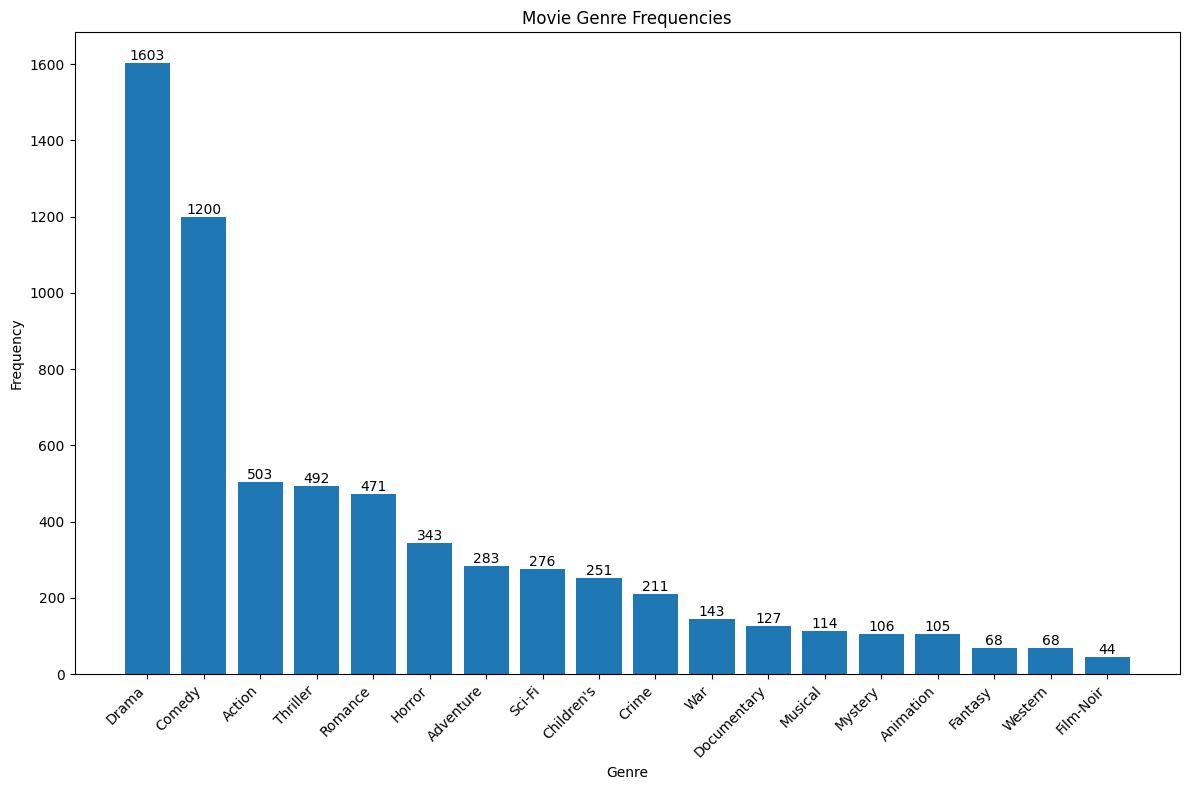

In [267]:
plt.figure(figsize=(12, 8))
bars = plt.bar(df_genres["Genre"], df_genres["Count"])
plt.xlabel("Genre")
plt.ylabel("Frequency")
plt.title("Movie Genre Frequencies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
    )

plt.show()


* Visualize the bar plot showing no.of movies released in a particular year

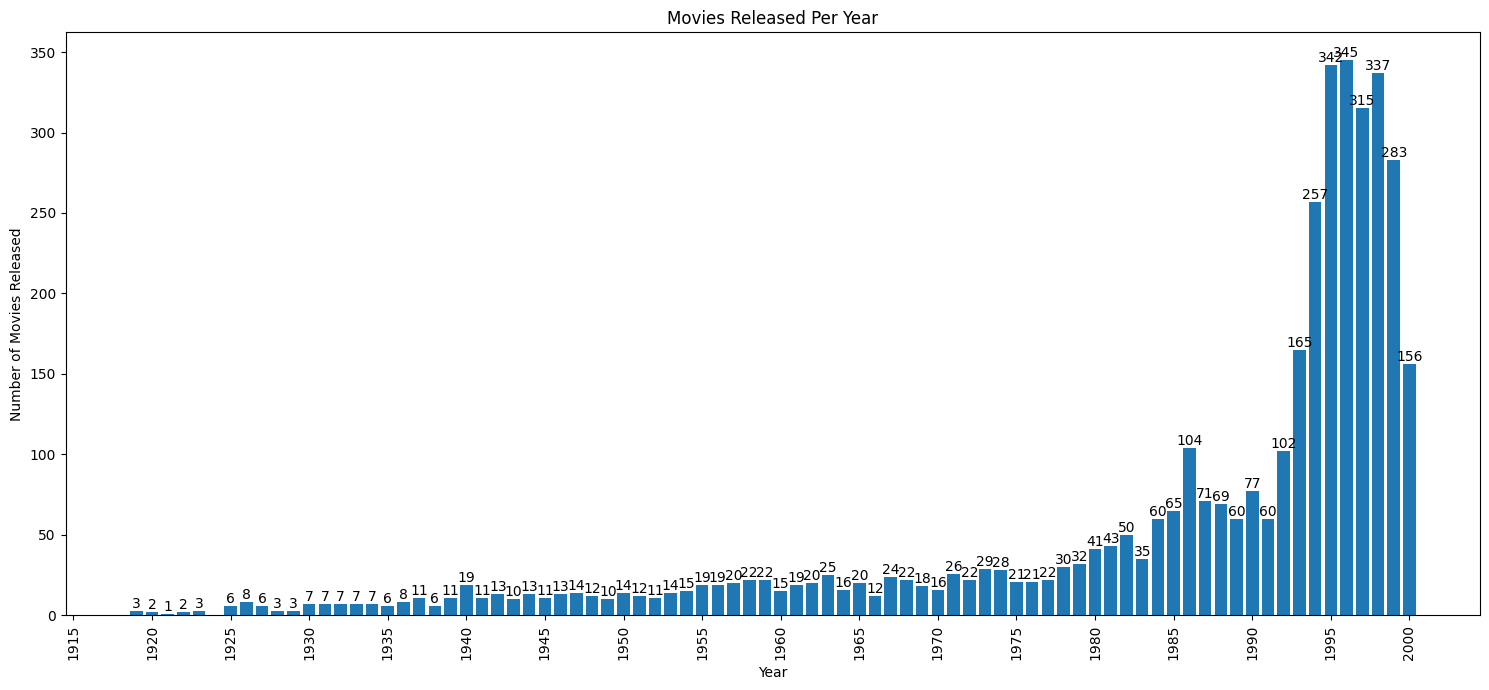

In [268]:
# YOUR CODE HERE
import re

rows = session.execute("SELECT title FROM data_movies;")
year_pattern = re.compile(r"\((\d{4})\)")
years = [
    int(match.group(1)) for row in rows if (match := year_pattern.search(row.title))
]
year_counts = Counter(years)
df_years = pd.DataFrame(year_counts.items(), columns=["Year", "Count"]).sort_values(
    "Year"
)

plt.figure(figsize=(15, 7))
bars = plt.bar(df_years["Year"], df_years["Count"])
plt.xlabel("Year")
plt.ylabel("Number of Movies Released")
plt.title("Movies Released Per Year")
plt.xticks(rotation=90)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(5))
plt.tight_layout()
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
    )

plt.show()


* Depict the plot of Age groups ratio who are active in watching movies

**Hint:** Use the following query.

query = 'select age from cds_mov.data_users;'

In [269]:
# YOUR CODE HERE
rows = session.execute("SELECT age FROM data_users;")
ages = [row.age for row in rows]
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ["Under 18", "18-24", "25-34", "35-44", "45-54", "55+"]
age_groups = pd.cut(ages, bins=bins, labels=labels, right=False)
age_group_counts = age_groups.value_counts().sort_index()


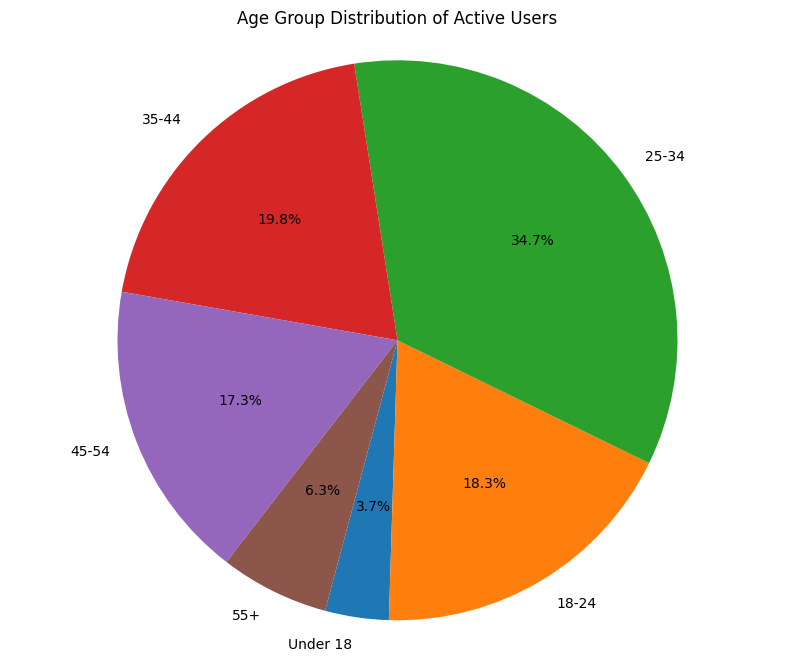

In [270]:
plt.figure(figsize=(10, 8))
plt.pie(
    age_group_counts, labels=age_group_counts.index, autopct="%1.1f%%", startangle=255
)
plt.title("Age Group Distribution of Active Users")
plt.axis("equal")
plt.show()


### Analyzing the Data (3 points)

Analyzing the correlation between the movies records, implement a function to recommend movies based on search term

* Retrieve all the data from ratings table

**Hint:** Use the following query.

query = 'select * from cds_mov.data_ratings;'

In [271]:
# YOUR CODE HERE
query = "SELECT * FROM data_ratings;"
rows = session.execute(query)
ratings_df = pd.DataFrame(list(rows))
print(f"\nRetrieved {len(ratings_df)} rows from the ratings table for analysis.")
ratings_df.shape



Retrieved 78050 rows from the ratings table for analysis.


(78050, 3)

* Create a movie matrix by applying pivot table with the above retrieved ratings data

* use `pd.pivot_table` with index = `userid`, columns = `movieid` and Values = `rating`

 **Hint:** create a dataframe with above retrieved ratings data to apply pivot table

In [272]:
ratings_df_smaller = ratings_df.head(50)
print(
    f"\nRetrieved {len(ratings_df_smaller)} rows from the ratings table for analysis."
)
ratings_df_smaller.shape



Retrieved 50 rows from the ratings table for analysis.


(50, 3)

In [273]:
# YOUR CODE HERE
# * Create a movie matrix by applying pivot table
movie_matrix = ratings_df_smaller.pivot_table(
    index="userid", columns="movieid", values="rating"
)
print("Movie matrix created successfully.")


Movie matrix created successfully.


In [274]:
movie_matrix.head()


movieid,10,110,356,480,485,527,552,589,590,595,...,2929,2970,3067,3181,3408,3448,3476,3481,3515,3536
userid,,,,,,,,,,,,,,,,,,,,,
13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Define a function named `recommend_movies()` which will take a movieid as argument and return the top 5 similar movieid's

    * Considering the argument (movieid) as search item collect the particular row data
    
    * Using movie matrix calculate correlation between movie search Item data and all the remaining data
    
        * Hint: [corr_with()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corrwith.html)
        
    * Sort the result by ascending order and return the top 5 items

In [275]:
# * Define a function named `recommend_movie()`
# def recommend_movie(movieId):
#     print(
#         f"Finding recommendations for movie ID: {movieId}, {type(movieId)}, {type(movie_matrix.columns[1])}"
#     )
#     print(movie_matrix.columns)
#     if movieId not in movie_matrix.columns:
#         return f"Movie ID {movieId} not found in the ratings matrix."
#     movie_ratings = movie_matrix[movieId]
#     print(f"Movie ratings for movie ID {movieId}:\n{movie_ratings}")

#     similar_to_movie = movie_matrix.corrwith(movie_ratings)
#     print(f"Similar movies correlation:\n{similar_to_movie}")

#     corr_df = pd.DataFrame(similar_to_movie, columns=["Correlation"])
#     corr_df.dropna(inplace=True)
#     # Add a count of ratings to filter out movies with few ratings
#     ratings_count = ratings_df.groupby("movieid")["rating"].count()
#     corr_df = corr_df.join(ratings_count.rename("rating_count"))
#     # Filter for movies with more than 10 ratings for better recommendations
#     top_recommendations = corr_df[corr_df["rating_count"] > 10].sort_values(
#         "Correlation", ascending=False
#     )
#     # Exclude the movie itself and return top 5
#     return top_recommendations.iloc[1:6].index.tolist()


In [276]:
def recommend_movie(movieId):
    try:
        # Get ratings for the input movie
        movie_ratings = movie_matrix[movieId]

        # Calculate correlation with other movies
        similar_movies = movie_matrix.corrwith(movie_ratings)

        # Remove NA values and sort
        similar_movies = similar_movies.dropna().sort_values(ascending=False)

        # Return top 5 similar movies (excluding the input movie itself)
        return similar_movies.index[1:6].tolist()
    except KeyError:
        return []


* write a query to get MovieId of a Title (your choice) and the result MovieId as a search item by calling the above defined function

In [277]:
# YOUR CODE HERE
list_of_recommended_movies = recommend_movie(480)
list_of_recommended_movies


/Users/rajranja/Documents/github/rajiv-ranjan/cds-mini-projects/m7/mp-1/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/rajranja/Documents/github/rajiv-ranjan/cds-mini-projects/m7/mp-1/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Users/rajranja/Documents/github/rajiv-ranjan/cds-mini-projects/m7/mp-1/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


[]

In [278]:
# YOUR CODE HERE
list_of_recommended_movies = recommend_movie(1)
list_of_recommended_movies


[]

In [279]:
# YOUR CODE HERE
list_of_recommended_movies = recommend_movie(110)
list_of_recommended_movies


[]

In [280]:
target_title = "Toy Story (1995)"
# target_title = "Contact (1997)"  # Example movie title to search for
query = (
    f"SELECT movieid FROM data_movies WHERE title = '{target_title}' ALLOW FILTERING;"
)
result = session.execute(query).one()
if result:
    target_movie_id = result.movieid
    print(f"\nThe MovieId for '{target_title}' is {target_movie_id}")
    recommendations = recommend_movie(target_movie_id)
    print(f"Top 5 recommended movie IDs are: {recommendations}")

    # * Retrieve the Movie titles for the recommended IDs
    if recommendations:
        movie_ids_str = ", ".join(map(str, recommendations))
        query_titles = (
            f"SELECT title, genres FROM data_movies WHERE movieid IN ({movie_ids_str});"
        )

        print("\n--- Recommended Movies ---")
        recommended_movies = session.execute(query_titles)
        for movie in recommended_movies:
            print(f"- {movie.title} | Genres: {movie.genres}")
    else:
        print("Could not find enough similar movies with sufficient ratings.")
else:
    print(f"Movie '{target_title}' not found.")



The MovieId for 'Toy Story (1995)' is 1
Top 5 recommended movie IDs are: []
Could not find enough similar movies with sufficient ratings.


* Now taking the result of top 5 items (MovieId's) write a query to retrieve the Movie title from movies table

In [281]:
# YOUR CODE HERE
for m_id in recommendations:
    query = f"SELECT title FROM data_movies WHERE movieid = {m_id} ALLOW FILTERING"
    title = session.execute(query).one().title
    print(f"- {title}")


**Close the session**

In [282]:
# YOUR CODE HERE
print("\nShutting down the session and cluster.")
session.shutdown()
cluster.shutdown()
print("Connection closed.")



Shutting down the session and cluster.
Connection closed.
